# Import Libraries

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
import numpy as np
import os
import sys
import copy
import pandas as pd
import pretty_midi


sys.path.append('..')
import libfmp.b
import libfmp.c1
import libfmp.c3

# Please install the following libraries in the FMP environment
# Transkun (piano AMT model) 
# pip3 install transkun

# Basic pitch (pitch estimation and note transcription)
# pip install basic-pitch 

# Fluid Synth 
# !sudo apt install -y fluidsynth ([MacOS] brew install fluid-synth)
# !pip install --upgrade pyfluidsynth



# Transcription of Chopin's Prelude Using the Transkun Model

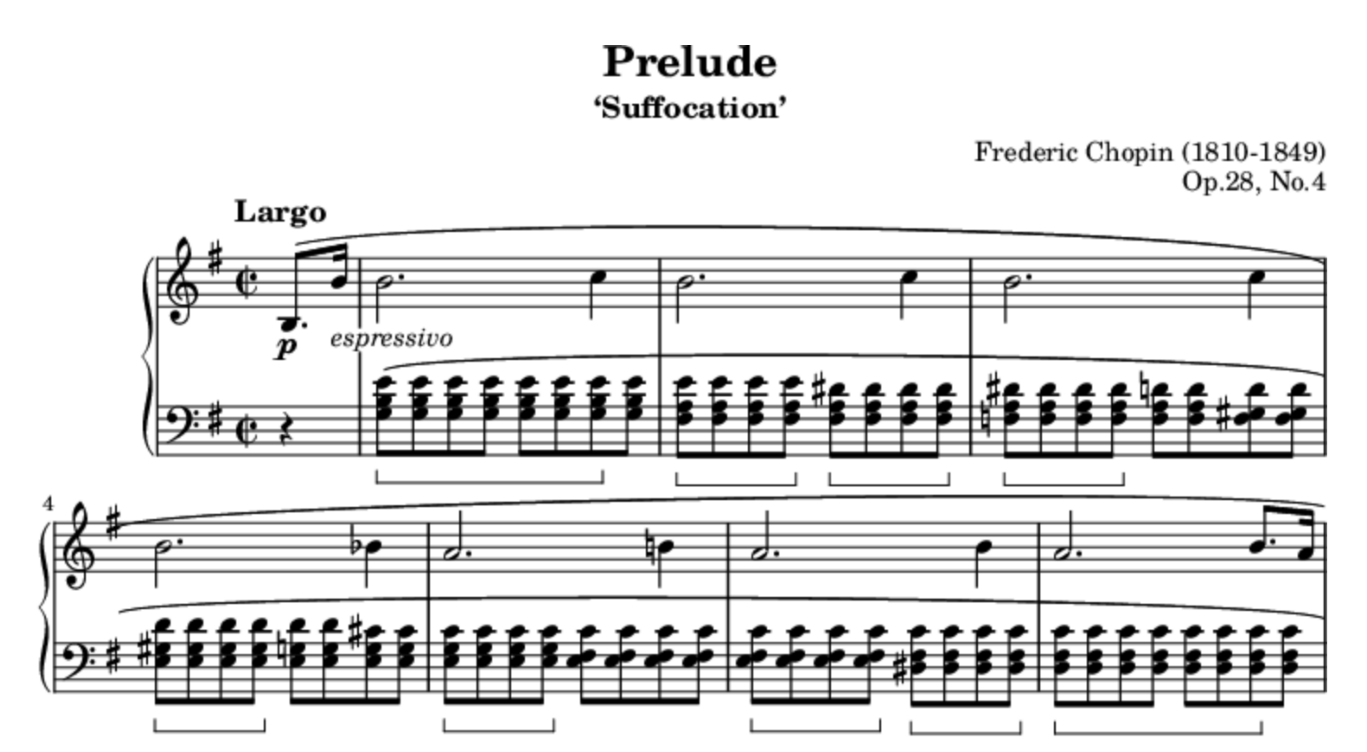

In [31]:
# Load score image
import matplotlib.image as mpimg
img = mpimg.imread('Chopin_Prelude_Op_24_No.4.png')

fig = plt.gcf()
fig.set_size_inches(12, 8) 

plt.imshow(img)
plt.axis('off') # Hide axes
plt.show()




In [3]:
# Convert audio to MIDI using the Transkun model

audio_file = '..f/audio/chopin_op28_no4.wav'
midi_file = '../audio/chopin_op28_no4.mid'

! transkun {audio_file} {midi_file}

/Users/juhan/anaconda3/envs/FMP/lib/python3.8/site-packages/torch/utils/checkpoint.py:31: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn("None of the inputs have requires_grad=True. Gradients will be None")


## Display the Piano Roll

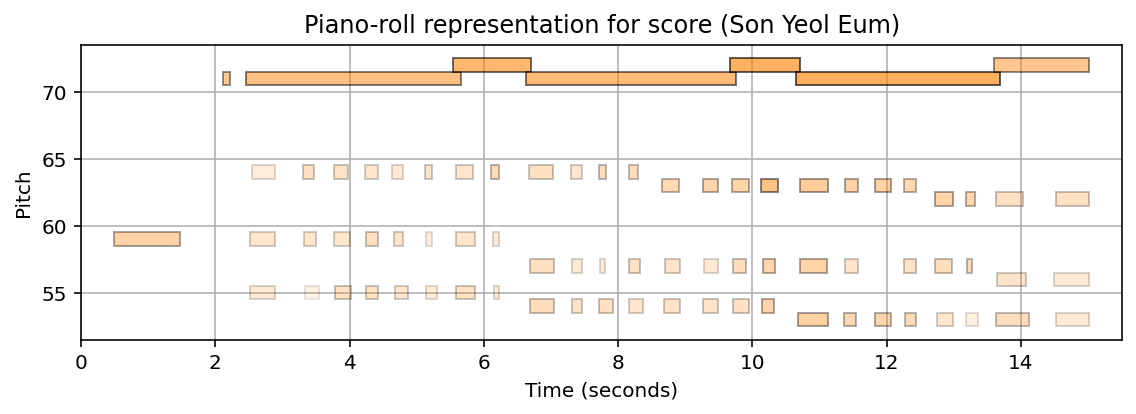

In [4]:
def midi_to_list(midi):
    """Convert a midi file to a list of note events

    Notebook: C1/C1S2_MIDI.ipynb

    Args:
        midi (str or pretty_midi.pretty_midi.PrettyMIDI): Either a path to a midi file or PrettyMIDI object

    Returns:
        score (list): A list of note events where each note is specified as
            ``[start, duration, pitch, velocity, label]``
    """

    if isinstance(midi, str):
        midi_data = pretty_midi.pretty_midi.PrettyMIDI(midi)
    elif isinstance(midi, pretty_midi.pretty_midi.PrettyMIDI):
        midi_data = midi
    else:
        raise RuntimeError('midi must be a path to a midi file or pretty_midi.PrettyMIDI')

    score = []

    for instrument in midi_data.instruments:
        for note in instrument.notes:
            start = note.start
            duration = note.end - start
            pitch = note.pitch
            velocity = note.velocity / 127.  # since midi velocity is in [0, 127]
            score.append([start, duration, pitch, velocity, instrument.name])
    return score


# Piano Roll Display 
score = midi_to_list(midi_file)
fig, ax = libfmp.c1.visualize_piano_roll(score, figsize=(8, 3), velocity_alpha=True);

ax.set_title('Piano-roll representation for score (Son Yeol Eum)')
ax.get_legend().remove()
plt.tight_layout()



## Synthesize MIDI using Fluid Synth

In [9]:
import fluidsynth
import pretty_midi

sr = 44100

pm = pretty_midi.PrettyMIDI(midi_file)
synth_audio = pm.fluidsynth(fs=sr)

ipd.Audio(synth_audio, rate=sr)

# Transcription of Beethoven's String Quartet  with the Basic-Pitch Model

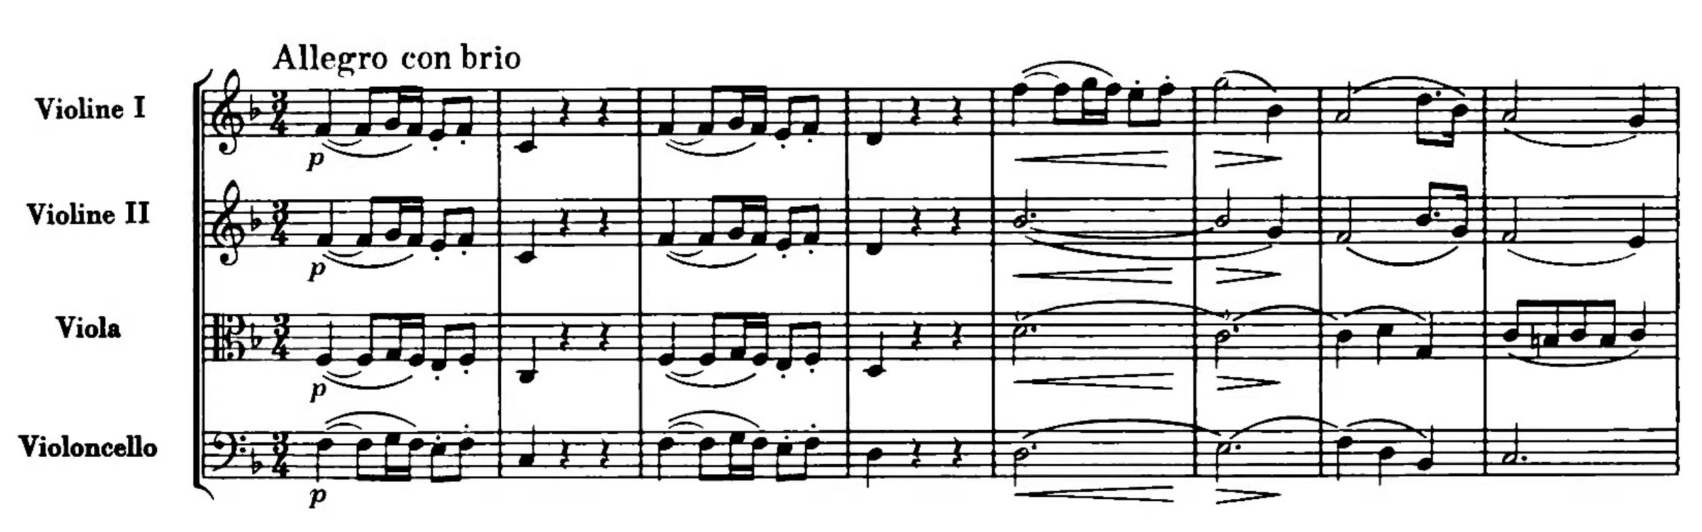

In [34]:
# Load score image
import matplotlib.image as mpimg
img = mpimg.imread('Beethovon_String_Quartet_No.1_Op_18.png')

fig = plt.gcf()
fig.set_size_inches(15, 10) 

plt.imshow(img)
plt.axis('off') # Hide axes
plt.show()


## Run the Basic-Pitch model

In [10]:
# Beethoven_strqrt.wav

from basic_pitch.inference import predict
from basic_pitch import ICASSP_2022_MODEL_PATH

audio_file = '../audio/Beethoven_strqrt.wav'
model_output, midi_data, note_events = predict(audio_file)



TensorFlow version 2.13.0 has not been tested with coremltools. You may run into unexpected errors. TensorFlow 2.12.0 is the most recent version that has been tested.
Minimum required torch version for importing coremltools.optimize.torch is 2.1.0. Got torch version 2.0.1.


Predicting MIDI for ../audio/Beethoven_strqrt.wav...


## Display Pitch Contour 

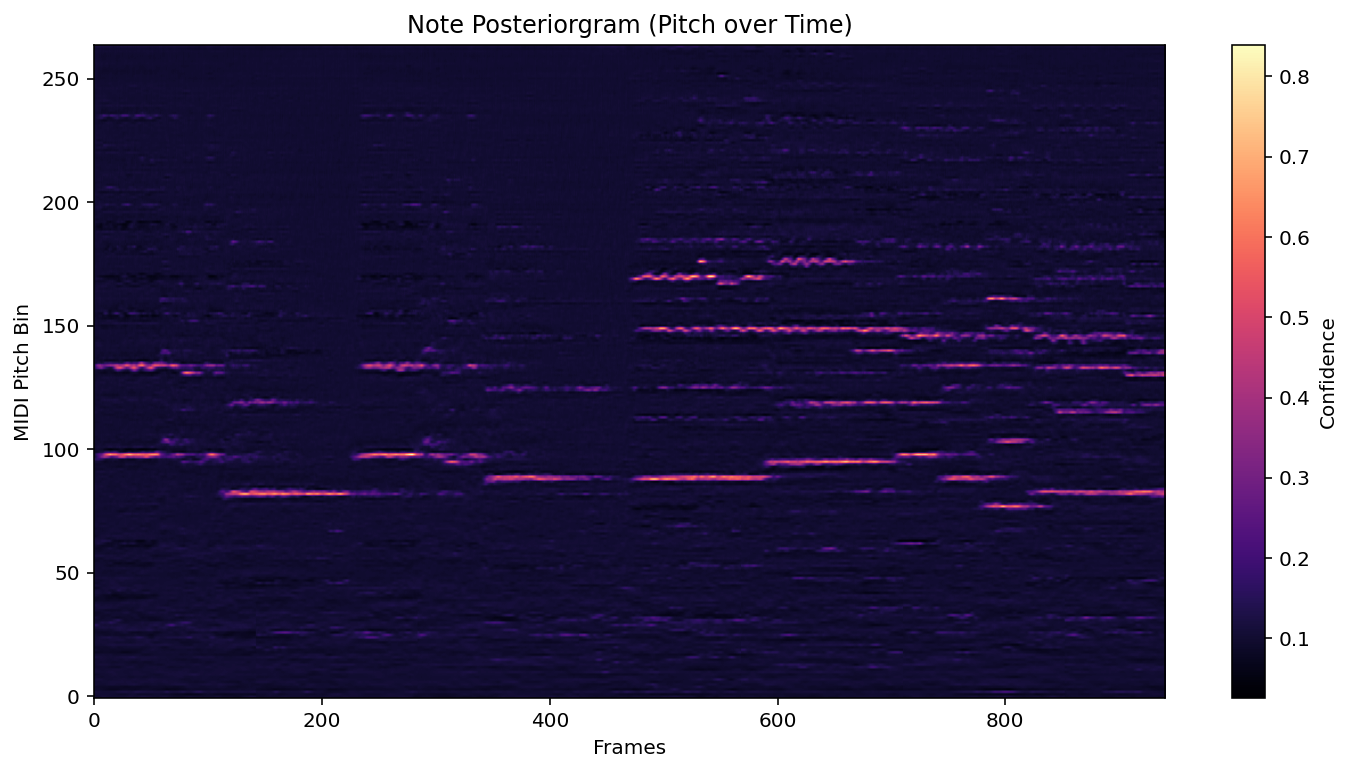

In [18]:
# model_output has 'onset', 'contour', and 'note'. You can use one of them

plt.figure(figsize=(12, 6))
plt.imshow(model_output['contour'].T, aspect='auto', origin='lower', cmap='magma')
plt.title("Note Posteriorgram (Pitch over Time)")
plt.xlabel("Frames")
plt.ylabel("MIDI Pitch Bin")
plt.colorbar(label="Confidence")
plt.show()

## Display Piano Roll 

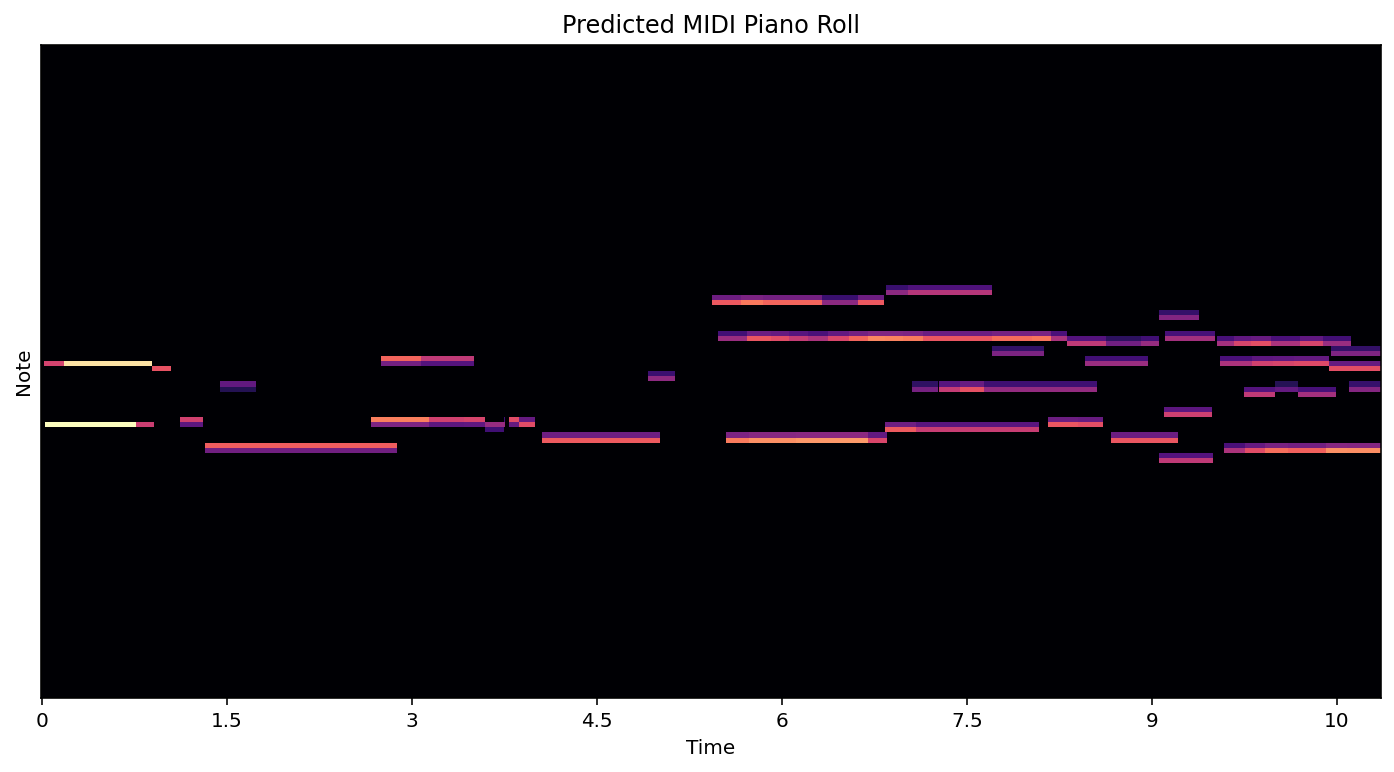

In [20]:
#import librosa.display

# Convert MIDI to a piano roll matrix
# fs=100 gives a 10ms resolution
piano_roll = midi_data.get_piano_roll(fs=100)

plt.figure(figsize=(12, 6))
librosa.display.specshow(piano_roll, x_axis='time', y_axis='cqt_note', hop_length=1, sr=100)
plt.title("Predicted MIDI Piano Roll")
plt.show()

## Display MIDI and Pitch Contour Together 

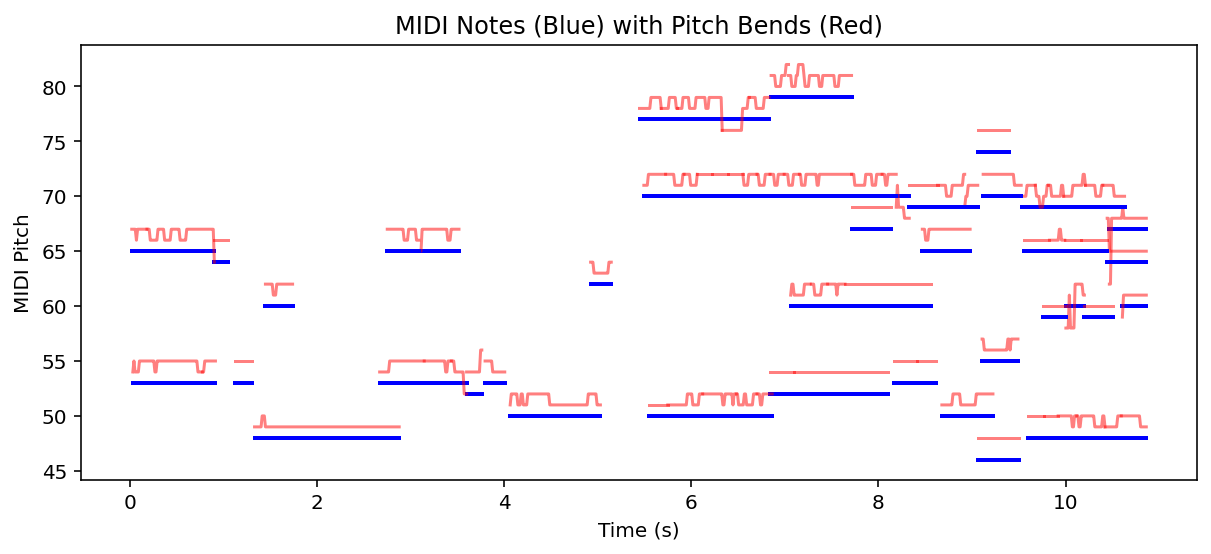

In [21]:
# Simple scatter plot of note events
plt.figure(figsize=(10, 4))
for start, end, pitch, velocity, pitch_bend in note_events:
    plt.plot([start, end], [pitch, pitch], color='blue', linewidth=2)
    if pitch_bend:
        # pitch_bend is a list of offsets in semitones
        times = np.linspace(start, end, len(pitch_bend))
        plt.plot(times, pitch + np.array(pitch_bend), color='red', alpha=0.5)

plt.title("MIDI Notes (Blue) with Pitch Bends (Red)")
plt.ylabel("MIDI Pitch")
plt.xlabel("Time (s)")
plt.show()